# Parameter calibration based on polarization test data — dynamic model

This notebook calibrates the undetermined physical parameters of the 1D static PEMFC model by fitting the simulated cell voltage to experimental measurements across 12 operating conditions (temperature, pressure, humidity).

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import optuna
from optuna.pruners import MedianPruner
from copy import deepcopy
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
import model.static as static_module
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

## Calibration setup

### Simulation setup
This step determines the accuracy and efficiency of the optimizer. Increasing the current point may increase the accuracy but definitely reduce the efficiency.

In [3]:
I_tested = [10, 20,30, 35]
RHC_tested = [0, 50]
PAC_tested = [1.3e5,1.4e5,1.5e5]
TFC_tested = [50, 60, 70]

In [4]:
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
polardata_exp = {sname: pd.read_excel(exp_pola_data, sheet_name=sname) for sname in exp_pola_data.sheet_names}

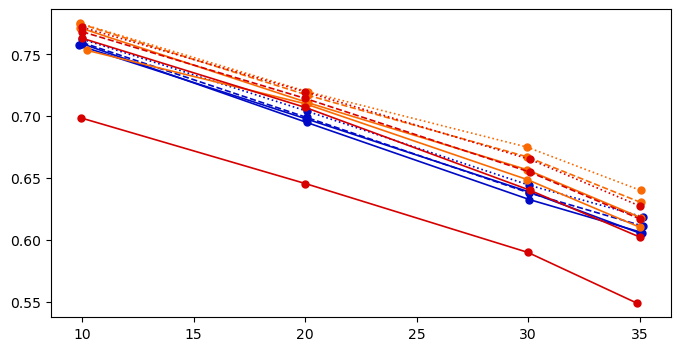

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, data in polardata_exp.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    idx_extracted = []
    for i_test in I_tested:
        idx_extracted.append(np.argmin((i_test - i_values) ** 2))
    plot_condition(ax, i_values[idx_extracted], v_values[idx_extracted], name, linewidth=1.2, markersize=5)

### Setup the simulation for all wanted conditions

In [6]:
def polartest_sim(parameters, cond_filter=None):
    """Run the static (algebraic) model across every (RHC, P, T) condition
    for which we have experimental data and return
    ``{cond_key: [Ucell at I_tested]}``. Returns ``False`` if any cell
    voltage came back NaN.

    Pass ``cond_filter(T, P, RHC) -> bool`` to restrict which conditions are
    simulated (used by the calibration-scenario loop).
    """
    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in polardata_exp:
                    continue
                if cond_filter is not None and not cond_filter(T_des, P_des, RHC):
                    continue

                Ucell_test = []
                for I_LOAD in I_tested:
                    Wout_c = 20 + I_LOAD * parameters["K_wout"]
                    Win_c  = 3  + I_LOAD * parameters["K_win"]
                    operating_inputs_stat = {
                        "Tfc": T_des + 273.15, "Phi_a_des": 0.0, "Phi_c_des": RHC / 100,
                        "Pa_des": P_des, "Pc_des": P_des,
                        "Win_c": Win_c, "Wout_c": Wout_c, "Win_a": 4.8, "Wout_a": 4.8,
                    }
                    model = PEMFC_stat(parameters, operating_inputs_stat)
                    sol = model.solve(I_LOAD / parameters["Aact"])
                    Ucell_test.append(model.cell_voltage(
                        I_LOAD / model.parameters["Aact"], sol, parameters, operating_inputs))
                    if any(math.isnan(v) for v in Ucell_test):
                        return False
                result[cond_key] = Ucell_test
    return result


In [7]:
def _experimental_ucell(cond_key):
    """Experimental cell voltage at every I_tested for one condition."""
    df = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return v_exp[idx]


def make_objective(cond_filter):
    """Return an optuna objective that fits only the conditions selected
    by ``cond_filter`` -- so a single objective function can be reused
    across the four calibration scenarios."""
    def objective(trial):
        params_trial = deepcopy(parameters)

        params_trial["OCV"]          = trial.suggest_float("OCV",          0.9,   1.0,  log=True)
        params_trial["i0_c_ref"]     = trial.suggest_float("i0_c_ref",     1e-2,  10,   log=True)
        params_trial["kappa_c"]      = trial.suggest_float("kappa_c",      1,     10,   log=True)
        params_trial["tau"]          = trial.suggest_float("tau",          1,     4,    log=True)
        params_trial["Re"]           = trial.suggest_float("Re",           1e-7,  1e-5, log=True)
        params_trial["epsilon_mc"]   = trial.suggest_float("epsilon_mc",   0.15,  0.4,  log=True)
        params_trial["epsilon_gdl"]  = trial.suggest_float("epsilon_gdl",  0.5,   0.7,  log=True)
        params_trial["epsilon_c"]    = trial.suggest_float("epsilon_c",    0.1,   0.3,  log=True)
        params_trial["epsilon_cl"]   = trial.suggest_float("epsilon_cl",   0.1,   0.4,  log=True)
        params_trial["a_slim"]       = trial.suggest_float("a_slim",       1e-2,  0.5,  log=True)
        params_trial["b_slim"]       = trial.suggest_float("b_slim",       1e-2,  0.5,  log=True)
        params_trial["a_switch"]     = trial.suggest_float("a_switch",     1e-2,  0.5,  log=True)
        params_trial["Hcl"]          = trial.suggest_float("Hcl",          1e-5,  2e-5, log=True)
        params_trial["Hgdl"]         = trial.suggest_float("Hgdl",         2e-4,  5e-4, log=True)
        params_trial["K_wout"]       = trial.suggest_float("K_wout",       0.1,   10,   log=True)
        params_trial["K_win"]        = trial.suggest_float("K_win",        0.1,   1,    log=True)

        try:
            polardata_sim = polartest_sim(params_trial, cond_filter=cond_filter)
        except Exception:
            return 100.0
        if polardata_sim is False or not polardata_sim:
            return 100.0

        error_sum = 0.0
        for cond_key, ucell_sim in polardata_sim.items():
            ucell_exp = _experimental_ucell(cond_key)
            error_sum += float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))
        return error_sum

    return objective


## Calibration scenarios
Compare the calibration result obtained when fitting the model against different subsets of the experimental polarization data. Edit `SINGLE_T`, `SINGLE_P`, `SINGLE_RHC`, `FIXED_P`, `FIXED_T` below if you want different anchor conditions.


In [8]:
# Anchor conditions for the partial calibration scenarios -- edit if you
# want different subsets. Defaults are picked so each scenario maps to at
# least one condition present in the experimental dataset.
SINGLE_T   = 60       # degrees C
SINGLE_P   = 1.4e5    # Pa
SINGLE_RHC = 50       # %         (RHC=0 is only available at P=1.3 bar)
TWO_HUM_T  = 70      # degrees C -- scenario "two humidifications"
TWO_HUM_P  = 1.3e5    # Pa        -- (RHC=0 and RHC=50 are both available at P=1.3 bar)
FIXED_P    = 1.3e5    # Pa  -- scenario "fixed pressure"
FIXED_T    = 60       # degrees C -- scenario "fixed temperature"

scenarios = {
    "one_condition":      {
        "label":  f"One condition (T={SINGLE_T}, P={SINGLE_P/1e5:.1f} bar, RHC={SINGLE_RHC})",
        "filter": lambda T, P, RHC: (T == SINGLE_T) and (P == SINGLE_P) and (RHC == SINGLE_RHC),
    },
    "two_humidification": {
        "label":  f"Two humidifications (P={TWO_HUM_P/1e5:.1f} bar, T={TWO_HUM_T}, RHC in {{0, 50}})",
        "filter": lambda T, P, RHC: (T == TWO_HUM_T) and (P == TWO_HUM_P) and (RHC in (0, 50)),
    },
    "fixed_pressure":     {
        "label":  f"Fixed pressure (P={FIXED_P/1e5:.1f} bar, all T, all RHC)",
        "filter": lambda T, P, RHC: P == FIXED_P,
    },
    "fixed_temperature":  {
        "label":  f"Fixed temperature (T={FIXED_T}, all P, all RHC)",
        "filter": lambda T, P, RHC: T == FIXED_T,
    },
    "all_data":           {
        "label":  "All conditions",
        "filter": lambda T, P, RHC: True,
    },
}


def conditions_in_scenario(filter_fn):
    """Return the cond_keys present in the experimental data that pass the filter."""
    keys = []
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                # Look up against whichever experimental-data dict this notebook uses.
                exp_data = globals().get("polardata_exp") or globals().get("hfrdata_exp") or {}
                if cond_key in exp_data and filter_fn(T_des, P_des, RHC):
                    keys.append(cond_key)
    return keys


for name, info in scenarios.items():
    matches = conditions_in_scenario(info["filter"])
    print(f"  {name:20s}  {len(matches):2d} conditions  -> {matches}")


  one_condition          1 conditions  -> ['T60_P400_HRC50']
  two_humidification     2 conditions  -> ['T70_P300_HRC0', 'T70_P300_HRC50']
  fixed_pressure         6 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
  fixed_temperature      4 conditions  -> ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
  all_data              12 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50', 'T50_P400_HRC50', 'T60_P400_HRC50', 'T70_P400_HRC50', 'T50_P500_HRC50', 'T60_P500_HRC50', 'T70_P500_HRC50']


In [9]:
# Run a separate optuna study for each scenario. The static model is
# algebraic so each trial is fast -- a short timeout already covers many
# trials. Total wall time is roughly (timeout per scenario) * 4.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

PER_SCENARIO_TIMEOUT = 180    # seconds
PER_SCENARIO_TRIALS  = 100000
N_JOBS               = 6

results = {}
for name, info in scenarios.items():
    print(f"\n=== Calibrating scenario: {name} ===")
    print(f"    {info['label']}")
    print(f"    conditions used: {conditions_in_scenario(info['filter'])}")
    study = optuna.create_study(direction="minimize")
    study.optimize(
        make_objective(info["filter"]),
        n_trials=PER_SCENARIO_TRIALS,
        timeout=PER_SCENARIO_TIMEOUT,
        n_jobs=N_JOBS,
        show_progress_bar=False,
    )

    # Re-run polartest_sim with the best params over ALL conditions so we
    # can later check how well each scenario generalises.
    params_best = deepcopy(parameters)
    params_best.update(study.best_params)
    sim_all     = polartest_sim(params_best, cond_filter=None)

    results[name] = {
        "label":           info["label"],
        "calibrated_keys": conditions_in_scenario(info["filter"]),
        "best_params":     study.best_params,
        "best_value":      study.best_value,
        "sim_all":         sim_all if sim_all is not False else {},
    }
    print(f"    best objective on the calibrated subset: {study.best_value:.4f}")



=== Calibrating scenario: one_condition ===
    One condition (T=60, P=1.4 bar, RHC=50)
    conditions used: ['T60_P400_HRC50']
    best objective on the calibrated subset: 0.0001

=== Calibrating scenario: two_humidification ===
    Two humidifications (P=1.3 bar, T=70, RHC in {0, 50})
    conditions used: ['T70_P300_HRC0', 'T70_P300_HRC50']
    best objective on the calibrated subset: 0.0066

=== Calibrating scenario: fixed_pressure ===
    Fixed pressure (P=1.3 bar, all T, all RHC)
    conditions used: ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
    best objective on the calibrated subset: 0.0120

=== Calibrating scenario: fixed_temperature ===
    Fixed temperature (T=60, all P, all RHC)
    conditions used: ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
    best objective on the calibrated subset: 0.0013

=== Calibrating scenario: all_data ===
    All conditions
    conditions used: ['T50_P300_

## Best parameters side-by-side
How much do the calibrated parameters change as you broaden the training set? Big swings here indicate the parameter is poorly constrained by the partial dataset.


In [10]:
# Side-by-side parameter comparison.
param_df = pd.DataFrame({name: info["best_params"] for name, info in results.items()})
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))


             one_condition  two_humidification  fixed_pressure  fixed_temperature  all_data
OCV                 0.9102              0.9237          0.9344             0.9172    0.9179
i0_c_ref             4.637              0.9205          0.1677              1.925     3.205
kappa_c              1.722               1.043           2.113              1.898      1.42
tau                  1.599               2.322           2.255              2.935     1.733
Re               1.951e-07           7.914e-06       1.766e-06          1.111e-06 2.273e-06
epsilon_mc          0.1786              0.2799          0.2827             0.3928    0.1962
epsilon_gdl         0.6674               0.639          0.5946             0.6097    0.6718
epsilon_c           0.1127              0.2234          0.2715             0.1721    0.2103
epsilon_cl          0.1001              0.1024          0.1001             0.1001    0.1002
a_slim              0.4702              0.4574         0.03754            0.0430

## Compare best-fit polarization curves across scenarios
The helper `plot_scenario_fit(name)` produces two figures for one scenario:
1. **USED for calibration** — one mini-panel per condition that was actually fitted; if the optimization worked these should match closely.
2. **ALL conditions** — the same plot but over every operating condition. Held-out conditions reveal how well the calibrated parameters generalize. Panel titles tagged `[CAL]` mark conditions that were used during calibration.


In [11]:
import math

def plot_scenario_fit(name):
    """Produce two per-condition grids for a calibration scenario:
    1. only the conditions used in the fit
    2. every condition in the experimental dataset
    Blue solid markers = experiment, red dotted squares = simulation.
    """
    info = results[name]
    cal_set = set(info["calibrated_keys"])

    panels_to_show = [
        ("USED for calibration", info["calibrated_keys"]),
        ("ALL conditions",       list(polardata_exp.keys())),
    ]
    for title_suffix, keys in panels_to_show:
        n = len(keys)
        if n == 0:
            print(f"({name}: no conditions for '{title_suffix}')")
            continue
        ncols = min(4, max(1, n))
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, cond_key in zip(axes.flatten(), keys):
            ucell_exp = _experimental_ucell(cond_key)
            ucell_sim = info["sim_all"].get(cond_key)
            ax.plot(I_tested, ucell_exp, "o-", color="tab:blue",
                    linewidth=1.4, label="experiment")
            if ucell_sim is not None:
                ax.plot(I_tested, ucell_sim, "s:", color="tab:red",
                        linewidth=1.2, label="simulated")
                ax.set_ylim(np.max([np.min(ucell_sim)*0.95, 0]), np.max(ucell_sim)*1.05)
            in_cal = cond_key in cal_set
            tag = "[CAL] " if in_cal else ""
            ax.set_title(f"{tag}{cond_key}", fontsize=8,
                         color="tab:green" if in_cal else "black")
            ax.grid(True, alpha=0.3)
        for ax in axes.flatten()[n:]:
            ax.set_visible(False)
            
        axes.flatten()[0].legend(fontsize=8, loc="best")
        fig.suptitle(f"{info['label']}  --  {title_suffix}\n"
                     f"objective on calibrated subset = {info['best_value']:.4f}",
                     fontsize=10)
        fig.tight_layout()
        plt.show()


### Scenario: `one_condition`
Two figures — fit on the calibrated subset first, then on every experimental condition.


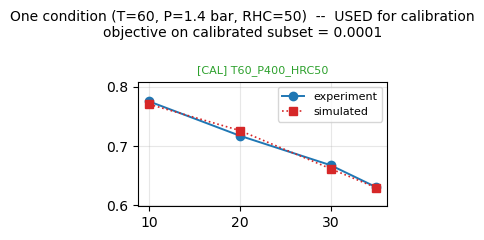

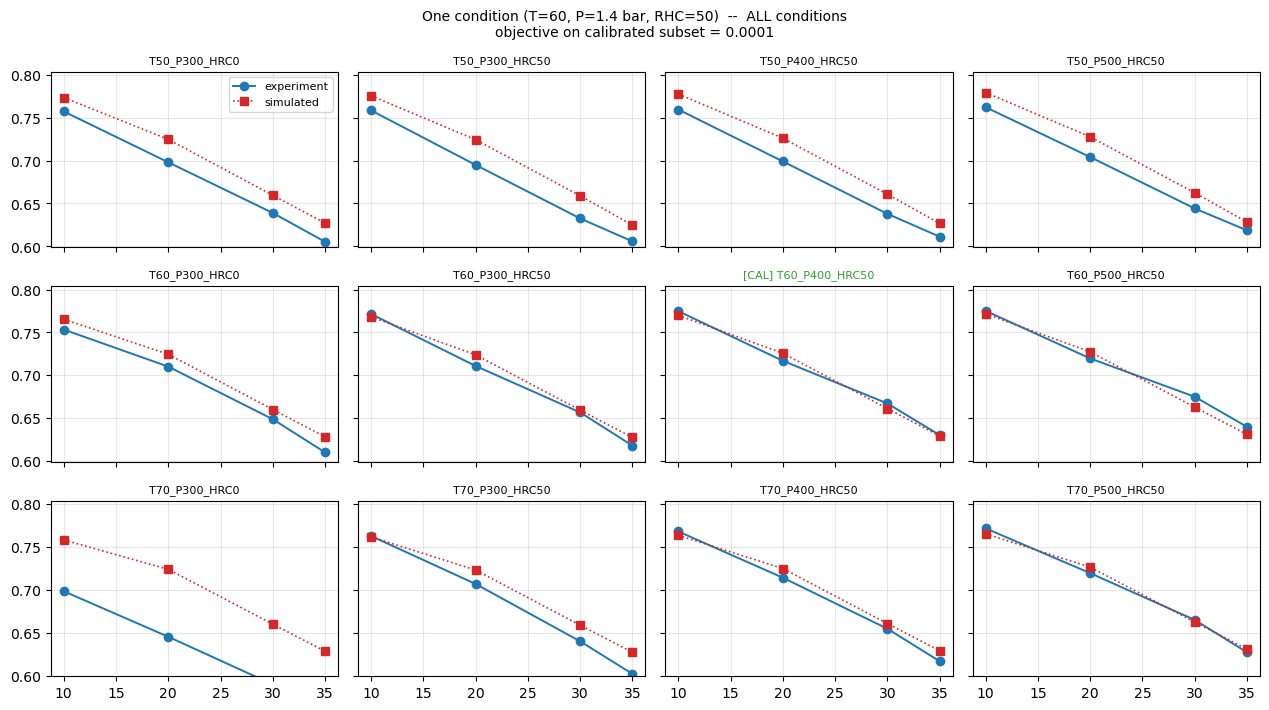

In [12]:
plot_scenario_fit("one_condition")

### Scenario: `two_humidification`
Fit on the two operating conditions that share P and T but differ in cathode humidification (RHC = 0 and 50).


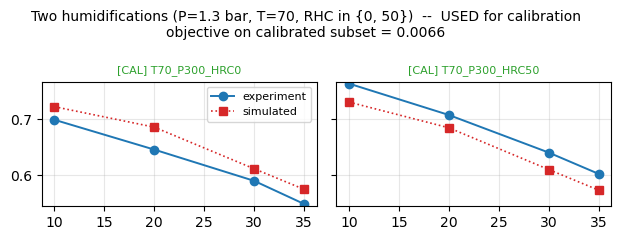

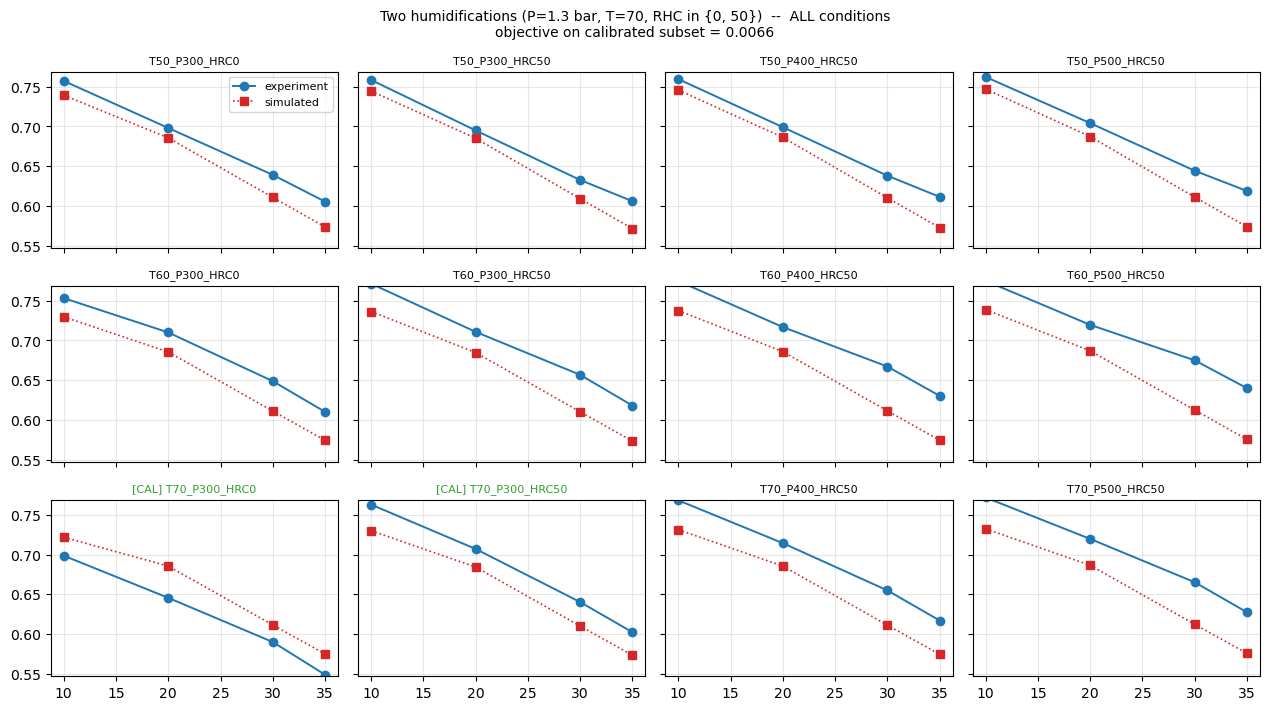

In [13]:
plot_scenario_fit("two_humidification")


### Scenario: `fixed_pressure`
Two figures — fit on the calibrated subset first, then on every experimental condition.


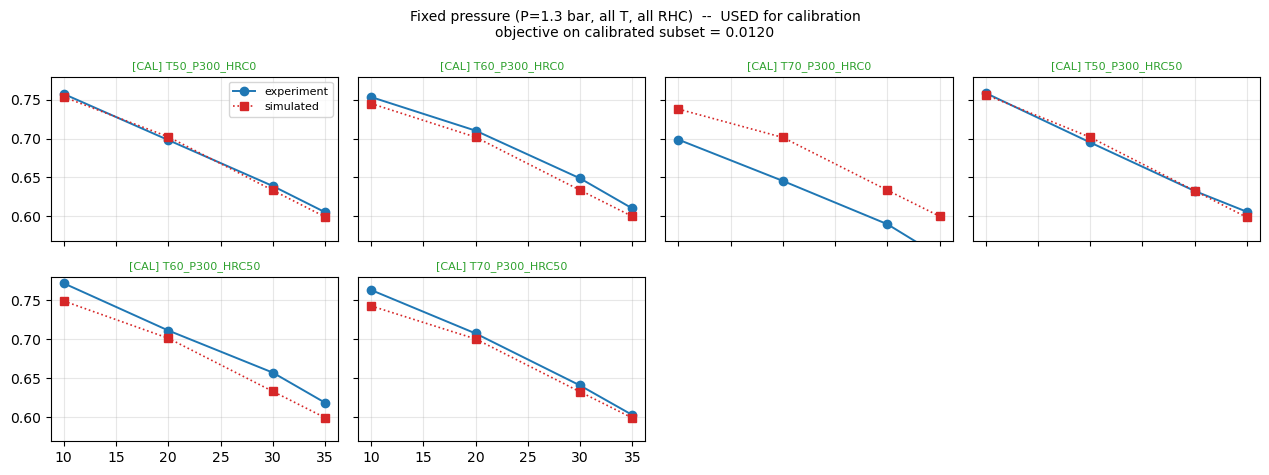

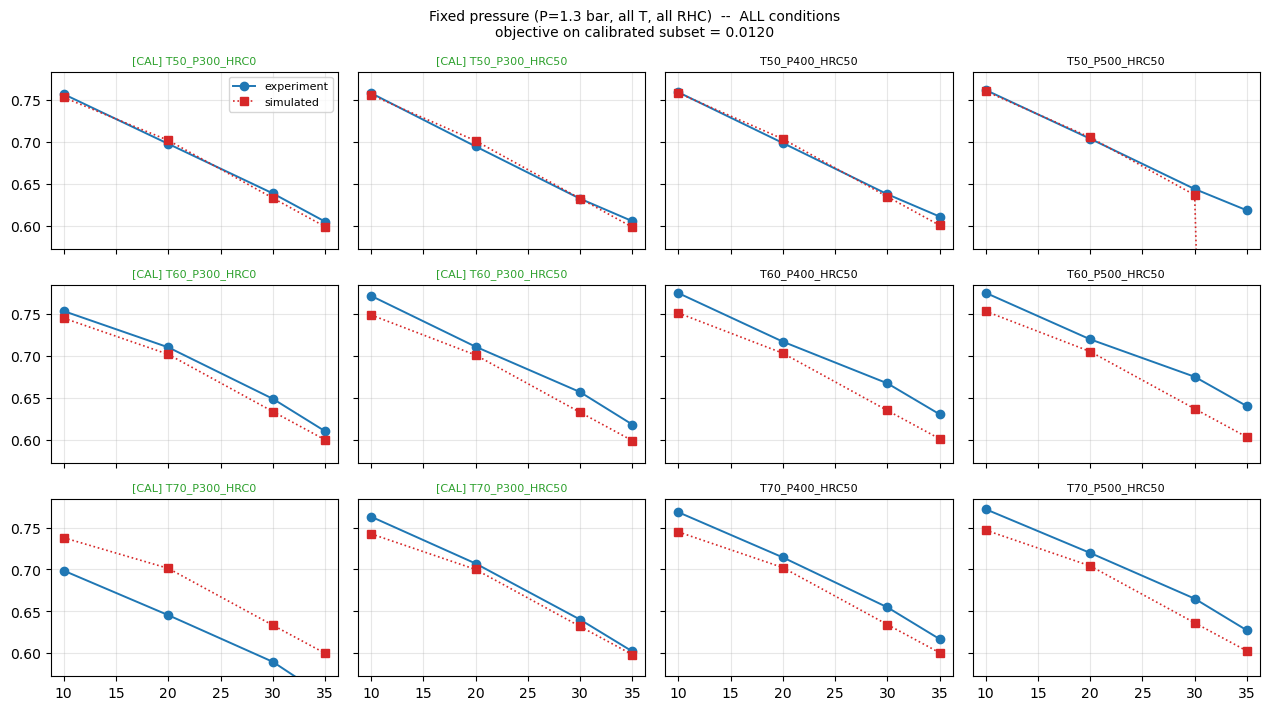

In [14]:
plot_scenario_fit("fixed_pressure")


### Scenario: `fixed_temperature`
Two figures — fit on the calibrated subset first, then on every experimental condition.


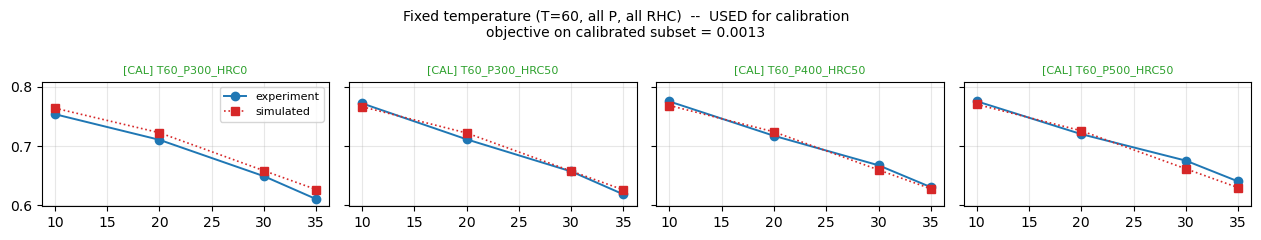

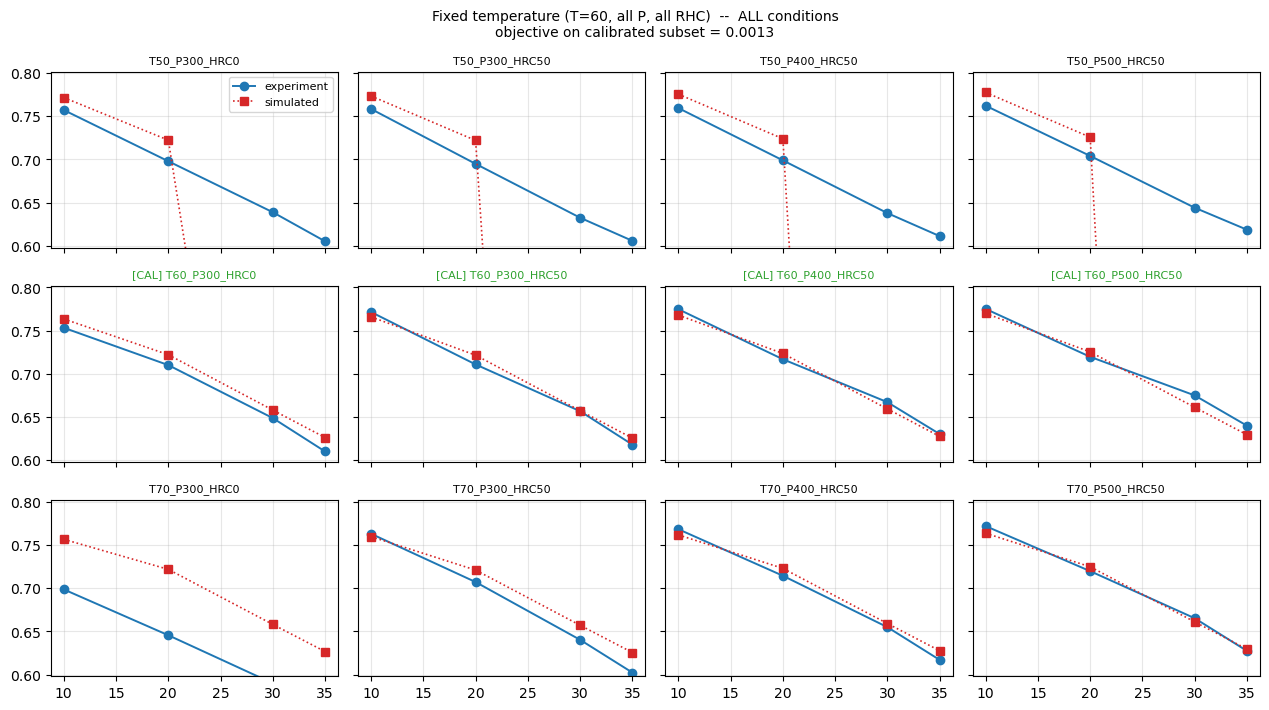

In [15]:
plot_scenario_fit("fixed_temperature")


### Scenario: `all_data`
Two figures — fit on the calibrated subset first, then on every experimental condition.


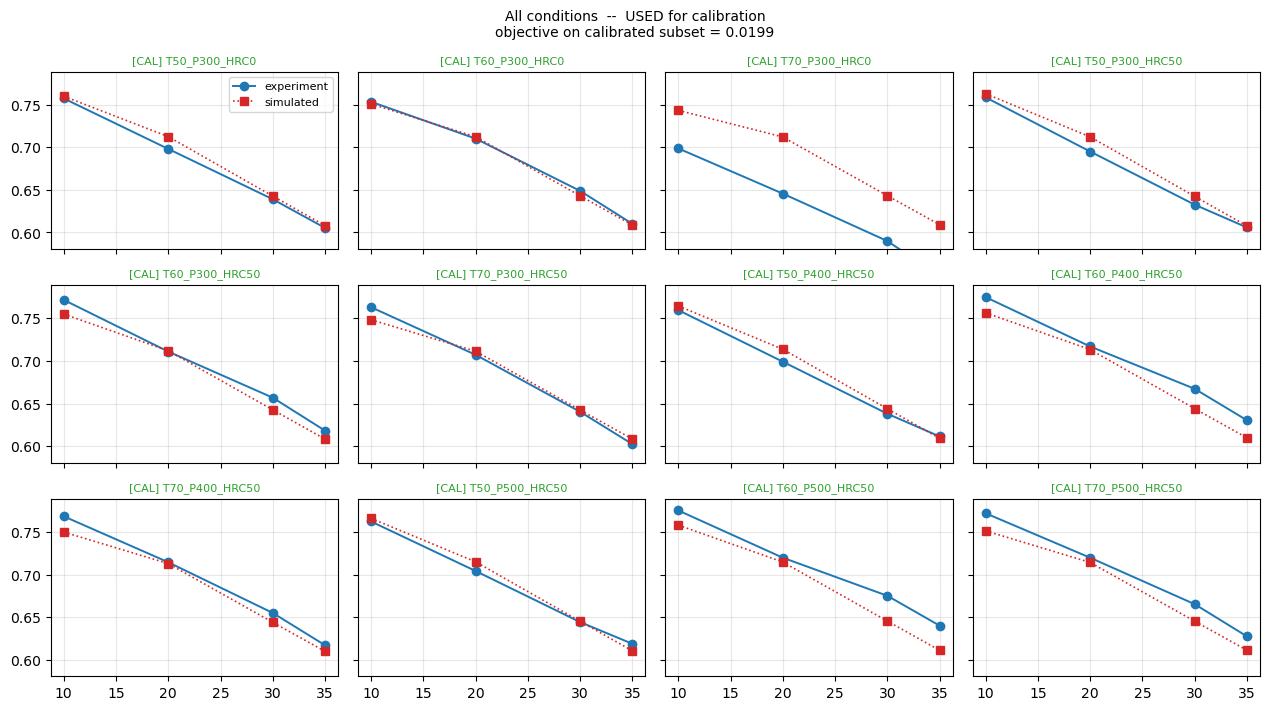

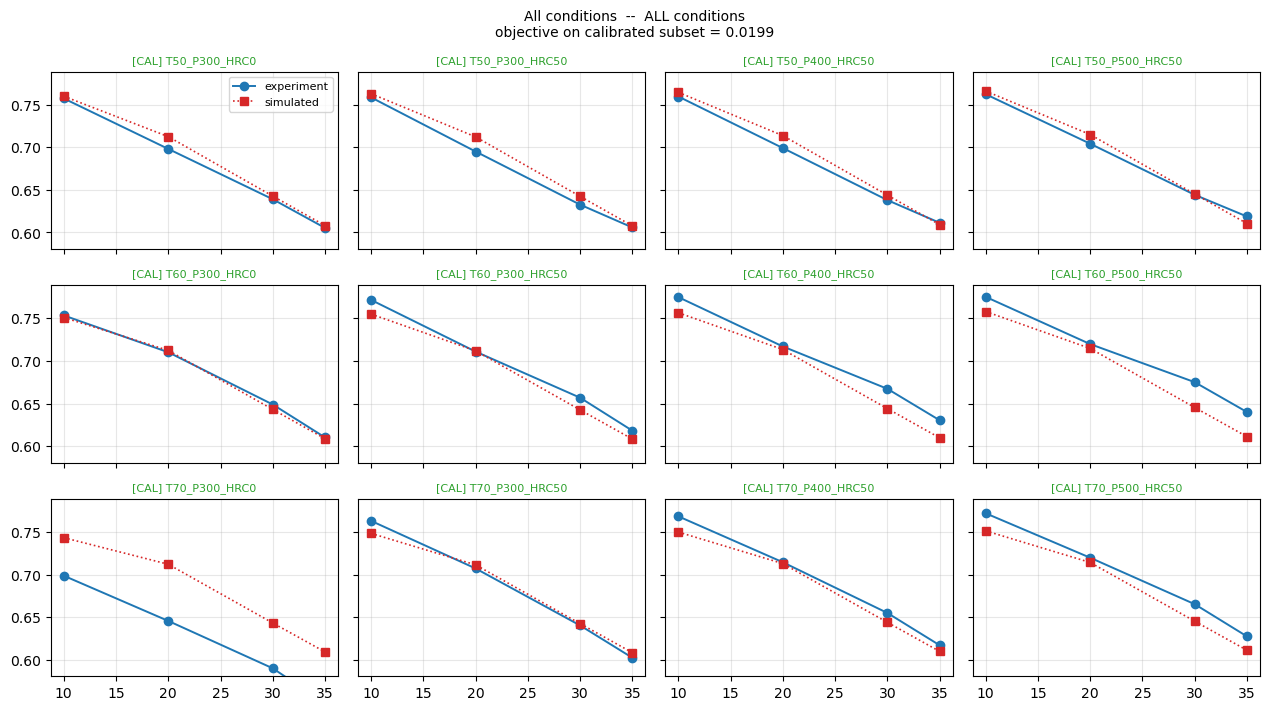

In [16]:
plot_scenario_fit("all_data")

## Residual heatmap
Each row is a calibration scenario, each column is one operating condition; the cell value is the sum of squared errors over the tested current points. Bright (low residual) on a column the scenario did NOT use during calibration tells you the scenario generalised; dark (large residual) tells you it did not.


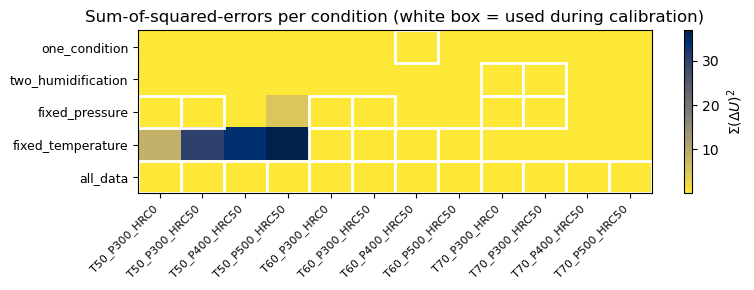

In [17]:
# Residual heatmap: scenarios (rows) x conditions (columns).
all_cond_keys = list(polardata_exp.keys())
n_scen = len(results)
residual_matrix = np.full((n_scen, len(all_cond_keys)), np.nan)
for i_scen, (name, info) in enumerate(results.items()):
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key not in info["sim_all"]:
            continue
        ucell_sim = np.array(info["sim_all"][cond_key])
        ucell_exp = _experimental_ucell(cond_key)
        residual_matrix[i_scen, i_cond] = float(np.sum((ucell_sim - ucell_exp) ** 2))

fig, ax = plt.subplots(figsize=(max(8, len(all_cond_keys) * 0.5), 0.5 + 0.5 * n_scen))
im = ax.imshow(residual_matrix, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(n_scen)); ax.set_yticklabels(list(results.keys()), fontsize=9)
ax.set_xticks(range(len(all_cond_keys)))
ax.set_xticklabels(all_cond_keys, rotation=45, ha="right", fontsize=8)
# Mark the cells that were USED for calibration with a black border.
for i_scen, (name, info) in enumerate(results.items()):
    cal_set = set(info["calibrated_keys"])
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key in cal_set:
            ax.add_patch(plt.Rectangle((i_cond - 0.5, i_scen - 0.5), 1, 1,
                                       fill=False, edgecolor="white", linewidth=2))
ax.set_title("Sum-of-squared-errors per condition (white box = used during calibration)")
fig.colorbar(im, ax=ax, label=r"$\Sigma(\Delta U)^2$")
plt.tight_layout()
plt.show()
